# Лабораторна робота №1

<b>Виконали:</b><br>
- Сачек Владислава КА-31
- Богданова Олександра КА-32
- Плахтій Злата КА-32

## Хід роботи:

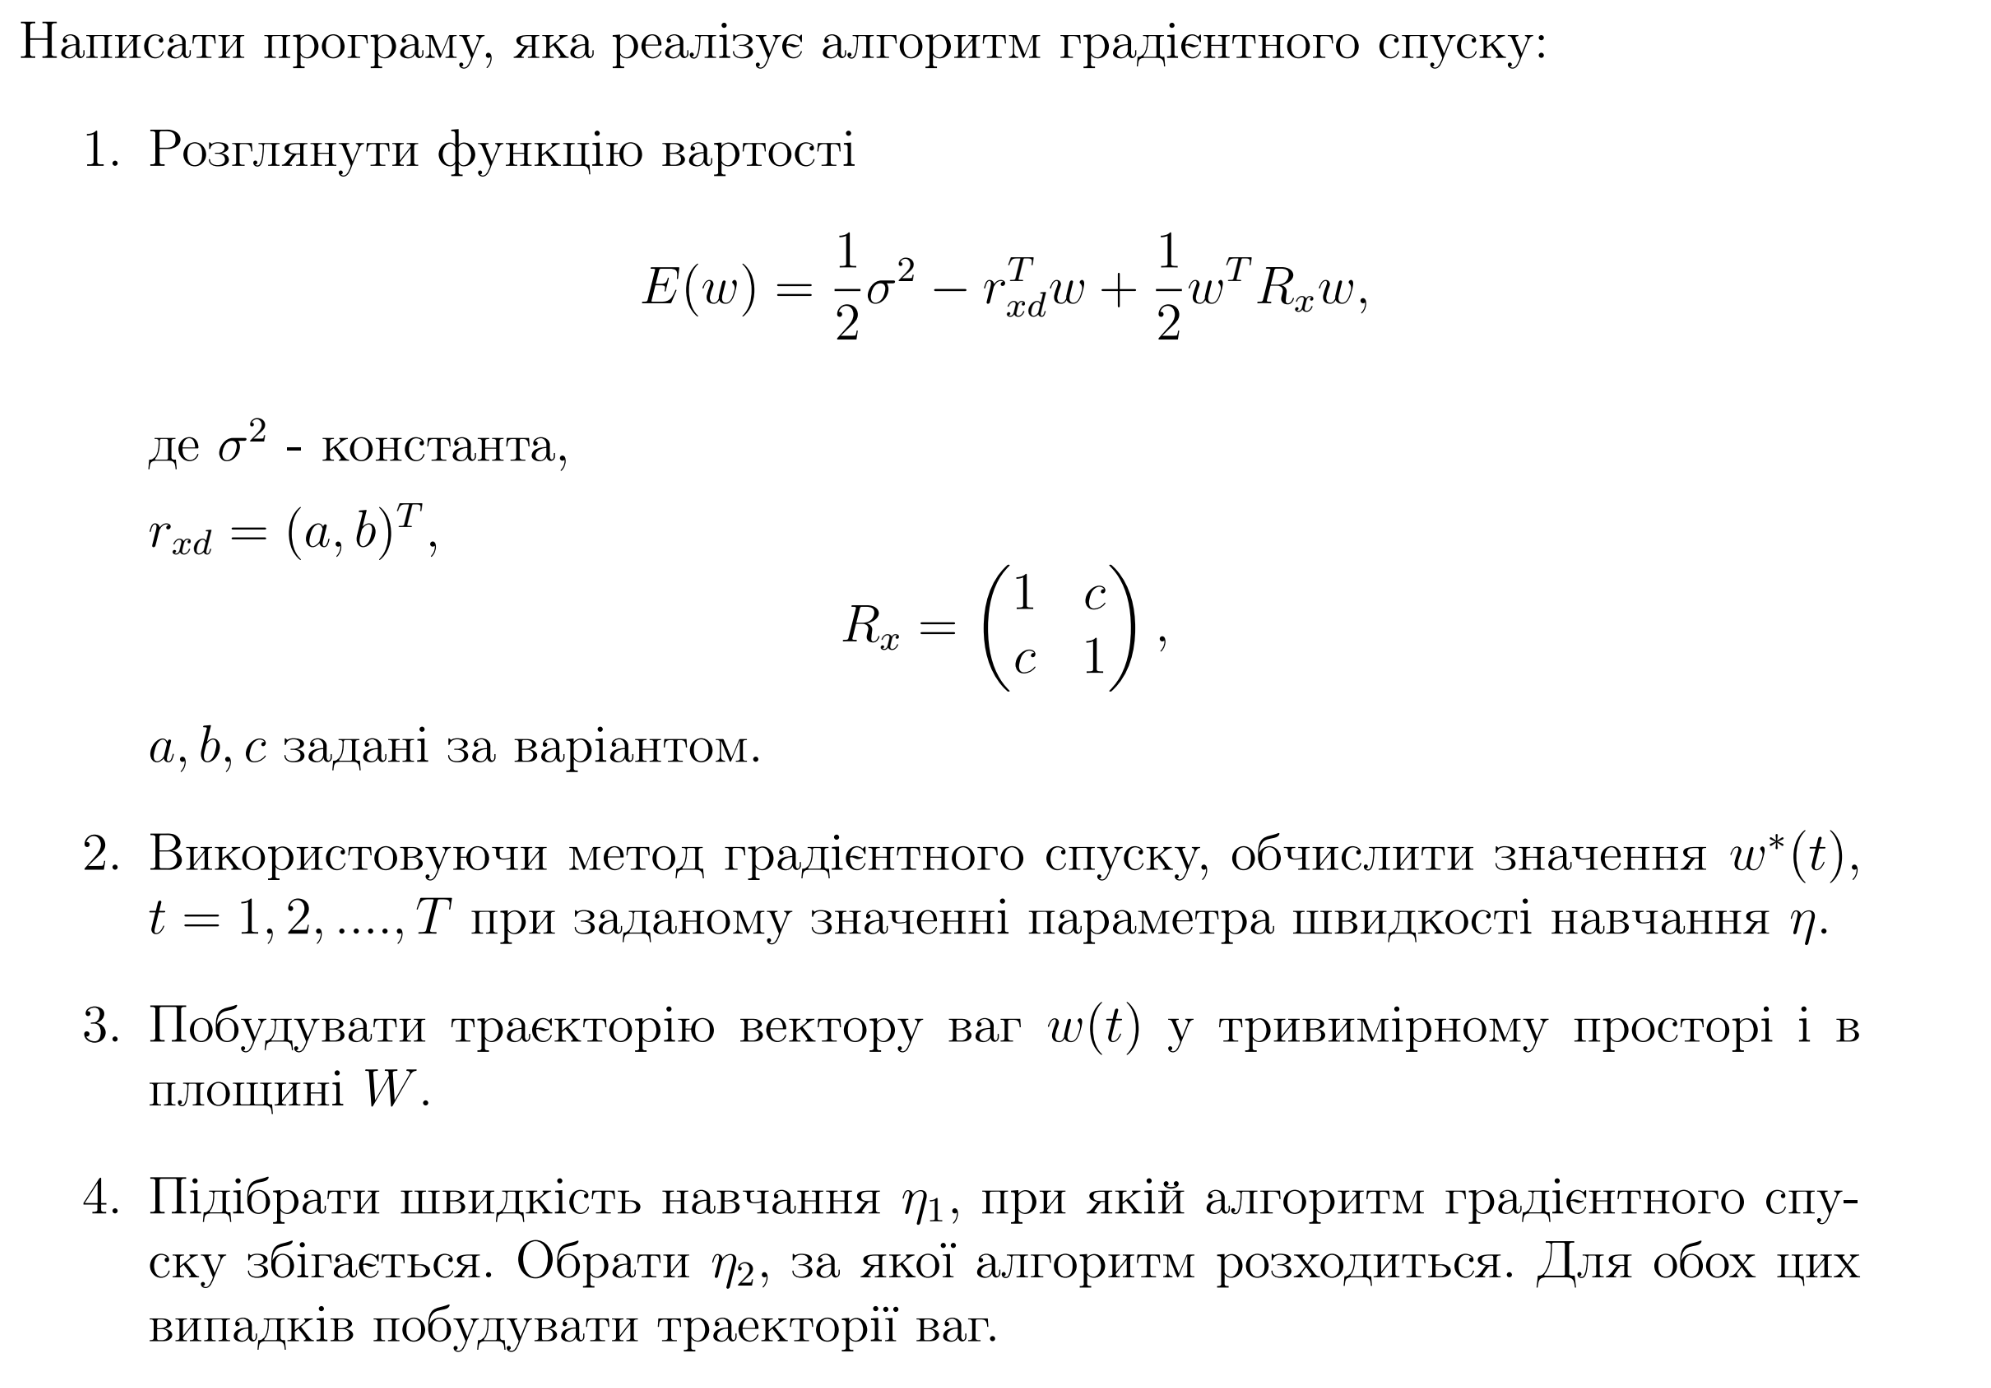
   
Аналогічно дослідити збіжність одного з адаптивних алгоритмів на вибір:
Adam, AdamaX, Adadelta, Adagrad, RMSProp, градієнтного методу з моментом.

Додати: 
- розрахунок w* за нормальним рівнянням (урок U-6);
- емпіричним шляхом перевірити умову збіжності алгоритму (слайд 10 уроку U-6);
- швидко чи повільно збігається алгоритм?

<b>Варіант завдання:</b><br>
2. a = 0.5, b = 0.6, c = 0.7, η = 1.6


### Алгоритм градієнтного спуску

Реалізуємо метод за ітераційною процедурою, де задається початковий вектор ваг $w_{0}$ і на кожній ітерації оновлення ваг відбувається як: 
$$w_{t+1} = w_t - η(Rw(t)−r)$$
Процес повторюється задані T ітерацій або до розбіжності.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Параметри варіанту 
a, b, c = 0.5, 0.6, 0.7
sigma2 = 1.0
r = np.array([a, b])
R = np.array([[1, c], [c, 1]])
eta2 = 1.6

def E(w):
    return 0.5*sigma2 - r @ w + 0.5 * w @ R @ w

def grad(w):
    return R @ w - r

def gradient_descent(eta, w0, T=60):
    w = w0.copy()
    hist = [w.copy()]
    for _ in range(T):
        w = w - eta * grad(w)
        hist.append(w.copy())
        if np.linalg.norm(w) > 1e6:
            break
    return np.array(hist)

### Розрахунок w* за нормальним рівнянням

Оскільки функція квадратична, її мінімум знаходиться з умови: 
$$\Delta E(w)= Rw - r =0$$
$$Rw = r$$
$$w^* = R^{-1}r$$
Таким чином отримуємо аналітичний мінімум $w^*$, що є точним, але вимагає доволі трудомісткого обчислення оберненої матриці $R^{-1}$.

In [17]:
w_star = np.linalg.solve(R, r)

print(f"w* = {w_star}")

w* = [0.15686275 0.49019608]


### Перевірка умови і швидкості збіжності алгоритму
Алгоритм градієнтного спуску збігається, якщо для кроку η виконується $0<η<2/λ_{max}$, де $λ_{max}$ - наайбільше власне число заданої матриці R:

In [18]:
lam_max = np.linalg.eigvalsh(R).max()
lam_min = np.linalg.eigvalsh(R).min()

eta_max = 2 / lam_max
lam_sp = lam_min / lam_max

print(f"η_max = {eta_max:.4f}")
print(f"λ_min/λ_max = {lam_sp:.4f}")

η_max = 1.1765
λ_min/λ_max = 0.1765


Отже, в нашому випадку алгоритм буде збігатися при значеннях η від 0 до 1.1765.  
Значення λ_min/λ_max = 0.176, тому можемо казати про помірну збіжність алгоритму.

### Вибір η1 і η2
Задане за умовою η=1.6 більше за η_max=1.1765, отже візьмемо цю швидкість навчання як ту, за якої алгоритм буде розходитись. Для збіжності алгоритму візьмемо значення з отриманого раніше діапазону - η1=0.8.

In [19]:
eta1 = 0.8  
eta2 = 1.6  
print(f"η1={eta1}  η2={eta2} ")

w0 = np.array([2.0, -1.5])
h1 = gradient_descent(eta1, w0)
h2 = gradient_descent(eta2, w0, T=25)

η1=0.8  η2=1.6 


### Графічні представлення
Побудуємо траєкторію ваг у тривимірному просторі і в площині W для η1=0.8 і η2=1.6, а також гафік швидкості збіжності $|E(t) - E^*|$

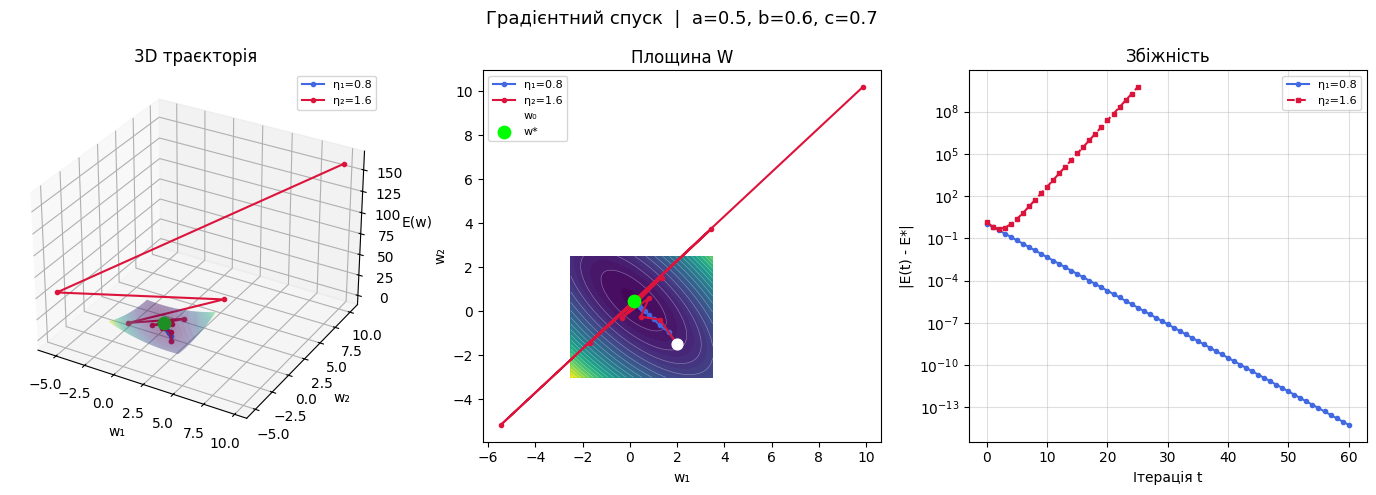

In [20]:
W1, W2 = np.meshgrid(np.linspace(-2.5, 3.5, 100), np.linspace(-3, 2.5, 100))
EE = np.vectorize(lambda w1, w2: E(np.array([w1, w2])))(W1, W2)

fig = plt.figure(figsize=(14, 5))
fig.suptitle(f"Градієнтний спуск  |  a={a}, b={b}, c={c}", fontsize=13)

# 3D
ax3 = fig.add_subplot(131, projection='3d')
ax3.plot_surface(W1, W2, EE, cmap='viridis', alpha=0.5, linewidth=0)
for h, col, lbl in [(h1,'royalblue',f'η₁={eta1}'), (h2,'crimson',f'η₂={eta2}')]:
    mask = np.abs(h).max(axis=1) < 15
    hw = h[mask]
    ax3.plot(hw[:,0], hw[:,1], [E(w) for w in hw], 'o-', color=col, ms=3, lw=1.5, label=lbl)
ax3.scatter(*w_star, E(w_star), color='lime', s=80, zorder=5)
ax3.set_xlabel('w₁'); ax3.set_ylabel('w₂'); ax3.set_zlabel('E(w)')
ax3.set_title('3D траєкторія'); ax3.legend(fontsize=8)

# Площина W
ax2 = fig.add_subplot(132)
ax2.contourf(W1, W2, EE, levels=40, cmap='viridis')
ax2.contour(W1, W2, EE, levels=20, colors='white', linewidths=0.4, alpha=0.4)
for h, col, lbl in [(h1,'royalblue',f'η₁={eta1}'), (h2,'crimson',f'η₂={eta2}')]:
    mask = np.abs(h).max(axis=1) < 15
    hw = h[mask]
    ax2.plot(hw[:,0], hw[:,1], 'o-', color=col, ms=3, lw=1.5, label=lbl)
ax2.scatter(*w0, color='white', s=60, zorder=5, label='w₀')
ax2.scatter(*w_star, color='lime', s=80, zorder=5, label='w*')
ax2.set_xlabel('w₁'); ax2.set_ylabel('w₂')
ax2.set_title('Площина W'); ax2.legend(fontsize=8)

# E(t)
ax_e = fig.add_subplot(133)
E1 = [E(w) for w in h1]
ax_e.semilogy(np.abs(E1 - E(w_star)), 'o-', color='royalblue', ms=3, lw=1.5, label=f'η₁={eta1}')
mask2 = np.abs(h2).max(axis=1) < 1e6
E2 = [E(w) for w in h2[mask2]]
ax_e.plot(range(len(E2)), E2, 's--', color='crimson', ms=3, lw=1.5, label=f'η₂={eta2}')
ax_e.set_xlabel('Ітерація t'); ax_e.set_ylabel('|E(t) - E*|')
ax_e.set_title('Збіжність'); ax_e.legend(fontsize=8); ax_e.grid(True, which='both', alpha=0.4)

plt.tight_layout()
plt.show()

З траєкторії ваг бачимо, що при η = 0.8 траєкторія за прямою лінією прямує до мінімуму, справді виконується збіжність $\lim_{k \to \infty} w(k) = w^*$
При η = 1.6 траєкторія віддаляється від мінімуму, коливання зростають, тобто підтверджується, що алгоритм розходиться.

### Адаптивний алгоритм Adam


Аналогічно дослідимо збіжність адаптивного алгоритму **Adam (Adaptive Moment Estimation)**, 
який поєднує ідеї градієнтного спуску з імпульсом та алгоритму RMSProp. 
На кожній ітерації Adam відстежує не лише напрямок градієнта, а й перший момент (середнє) та другий момент (дисперсію), що дозволяє адаптивно 
підбирати крок для кожного параметра окремо.

Формули оновлення моментів:

$$m_t = \beta_1 m_{t-1} + (1 - \beta_1)\, g_t$$

$$v_t = \beta_2 v_{t-1} + (1 - \beta_2)\, g_t^2$$

Оскільки початкові значення $m_0 = 0$ і $v_0 = 0$, на перших ітераціях моменти 
занижені. Для компенсації застосовують корекцію зміщення:

$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

Оновлення ваг:

$$w_{t+1} = w_t + \Delta w(t)$$

$$\Delta w_t = -\frac{\eta \cdot \hat{m}_t}{\sqrt{\hat{v}_t + \varepsilon}}$$

Реалізуємо алгоритм Adam та запускаємо його з двома значеннями швидкості навчання — 
збіжним η₁ = 0.1 та розбіжним η₂ = 100.

In [21]:
def adam(eta, w0, T=300, beta1=0.9, beta2=0.999, eps=1e-8):
    w  = w0.copy()
    m  = np.zeros_like(w)   # імпульс
    v  = np.zeros_like(w)   # дисперсія
    hist = [w.copy()]
    for t in range(1, T + 1):
        g = grad(w)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g**2
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        w = w - eta * m_hat / (np.sqrt(v_hat + eps))
        hist.append(w.copy())
        if np.linalg.norm(w) > 1e6:
            break
    return np.array(hist)

eta1_adam = 0.1    # збіжне
eta2_adam = 100.0  # розбіжне

ha1 = adam(eta1_adam, w0, T=300)
ha2 = adam(eta2_adam, w0, T=300)

Будуємо траєкторію вектору ваг w(t) у тривимірному просторі, у площині W 
та графік збіжності |E(t) – E*| для обох значень η.

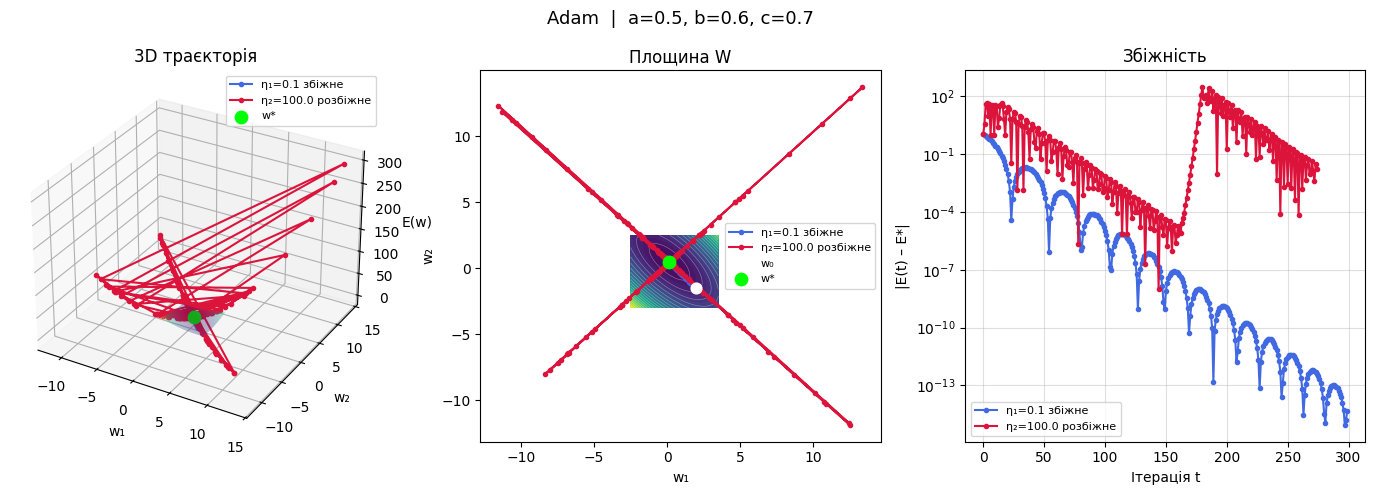

In [22]:
# Візуалізація Adam
W1, W2 = np.meshgrid(np.linspace(-2.5, 3.5, 100), np.linspace(-3, 2.5, 100))
EE = np.vectorize(lambda w1, w2: E(np.array([w1, w2])))(W1, W2)

fig = plt.figure(figsize=(14, 5))
fig.suptitle(f"Adam  |  a={a}, b={b}, c={c}", fontsize=13)

configs = [
    (ha1, 'royalblue', f'η₁={eta1_adam} збіжне'),
    (ha2, 'crimson',   f'η₂={eta2_adam} розбіжне'),
]

def clip(h):
    mask = np.abs(h).max(axis=1) < 15
    return h[mask]

# 3D траєкторія
ax3 = fig.add_subplot(131, projection='3d')
ax3.plot_surface(W1, W2, EE, cmap='viridis', alpha=0.4, linewidth=0)
for h, col, lbl in configs:
    hw = clip(h)
    ax3.plot(hw[:,0], hw[:,1], [E(w) for w in hw], 'o-', color=col, ms=3, lw=1.5, label=lbl)
ax3.scatter(*w_star, E(w_star), color='lime', s=80, zorder=5, label='w*')
ax3.set_xlabel('w₁'); ax3.set_ylabel('w₂'); ax3.set_zlabel('E(w)')
ax3.set_title('3D траєкторія'); ax3.legend(fontsize=8)

# Площина W
ax2 = fig.add_subplot(132)
ax2.contourf(W1, W2, EE, levels=40, cmap='viridis')
ax2.contour(W1, W2, EE, levels=20, colors='white', linewidths=0.4, alpha=0.4)
for h, col, lbl in configs:
    hw = clip(h)
    ax2.plot(hw[:,0], hw[:,1], 'o-', color=col, ms=3, lw=1.5, label=lbl)
ax2.scatter(*w0, color='white', s=60, zorder=5, label='w₀')
ax2.scatter(*w_star, color='lime', s=80, zorder=5, label='w*')
ax2.set_xlabel('w₁'); ax2.set_ylabel('w₂')
ax2.set_title('Площина W'); ax2.legend(fontsize=8)

# Збіжність |E(t) - E*|
ax_e = fig.add_subplot(133)
E_star = E(w_star)
for h, col, lbl in configs:
    vals = np.abs(np.array([E(w) for w in clip(h)]) - E_star)
    vals = vals[vals > 0]
    ax_e.semilogy(vals, 'o-', color=col, ms=3, lw=1.5, label=lbl)
ax_e.set_xlabel('Ітерація t'); ax_e.set_ylabel('|E(t) – E*|')
ax_e.set_title('Збіжність'); ax_e.legend(fontsize=8)
ax_e.grid(True, which='both', alpha=0.4)

plt.tight_layout()
plt.show()

При **η₁ = 0.1** алгоритм збігається — на графіку збіжності видно, що |E(t) – E*| 
монотонно спадає до нуля, а траєкторія у площині W плавно прямує до оптимуму w*. 
Збіжність хвилеподібна, що є характерною поведінкою Adam через адаптивне 
масштабування моментів.

При **η₂ = 100** алгоритм розбігається — траєкторія виходить далеко за межі області 
мінімуму, а значення |E(t) – E*| хаотично коливається і не зменшується. 
Це пояснюється тим, що при надто великому кроці адаптивне масштабування 
не встигає компенсувати розмір оновлення ваг.

## Висновки
>У ході роботи було досліджено алгоритм градієнтного спуску для мінімізації квадратичної функції вартості та проведено аналіз його збіжності. Метод градієнтного спуску було реалізовано ітераційною процедурою оновлення ваг за формулою $w_{t+1} = w_t - η(Rw(t)−r)$, також було отримано аналітичний розв’язок задачі мінімізації за нормальним рівнянням: $w^* = R^{-1}r$. Це значення використано як еталонний точний мінімум для подальшого порівняння з результатами чисельних методів. Для дослідження збіжності обчислено власні числа матриці R та визначено теоретичну умову збіжності 0 < η < 1.1765. Отримане граничне значення кроку навчання узгоджується з експериментальними результатами: при η=0.8 алгоритм стабільно збігається до аналітичного мінімуму, тоді як при η=1.6 спостерігається розбіжність і зростання норми вектора ваг.   
>   
>Також було досліджено адаптивний алгоритм Adam і показано, що при малому значенні параметра кроку алгоритм збігається до аналітичного мінімуму, а при надмірно великому кроці спостерігається розбіжність, однак адаптивний метод є менш чутливим до вибору параметрів порівняно з класичним градієнтним спуском. Адаптивний алгоритм забезпечує більш стабільну поведінку та може швидше зменшувати похибку завдяки автоматичному масштабуванню кроку за різними напрямами.